In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
data = pd.read_csv('Housing.csv')

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:

le = LabelEncoder()
data['mainroad'] = le.fit_transform(data['mainroad'])
data['guestroom'] = le.fit_transform(data['guestroom'])
data['basement'] = le.fit_transform(data['basement'])
data['hotwaterheating'] = le.fit_transform(data['hotwaterheating'])
data['airconditioning'] = le.fit_transform(data['airconditioning'])
data['prefarea'] = le.fit_transform(data['prefarea'])
data['furnishingstatus'] = le.fit_transform(data['furnishingstatus'])

In [ ]:
data['basement']

,basement
0,0
1,0
2,1
3,1
4,1
...,...
540,1
541,0
542,0
543,0


In [ ]:
ip = data.drop('price',axis=1)
op = data['price']

In [ ]:
train_ip, test_ip , train_op , test_op = train_test_split(ip,op,test_size=0.1,random_state=32)

In [ ]:
lin_model = LinearRegression()
lin_model.fit(train_ip,train_op)

LinearRegression()

In [ ]:
import pickle
with open('lin_model_file.pkl',mode='wb') as f:
    pickle.dump(lin_model,f)

In [ ]:

with open('lin_model_file.pkl',mode='rb') as a:
    lin_reg_model = pickle.load(a)

In [ ]:
pred_op = lin_reg_model.predict(test_ip)

In [ ]:
test_ip

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
443,4320,3,1,1,0,0,0,0,0,1,0,2
128,5500,3,1,3,1,1,0,0,1,1,0,0
79,6000,3,2,3,1,1,0,0,1,0,0,0
348,3150,2,2,1,0,0,1,0,0,0,0,1
335,3816,2,1,1,1,0,1,0,1,2,0,0
334,3290,2,1,1,1,0,0,1,0,1,0,0
65,8880,3,2,2,1,0,1,0,1,1,0,0
94,6000,4,2,4,1,0,0,0,0,1,0,1
17,8500,3,2,4,1,0,0,0,1,2,0,0
16,6600,4,2,2,1,1,1,0,1,1,1,2


In [ ]:
pred_op

array([2762853.08464627, 5947236.16909101, 6827796.68176491,
       3753474.09613705, 4945001.0479557 , 4146708.90052406,
       7476405.8237803 , 6376511.23016655, 8230423.0621382 ,
       7392354.76492662, 5229895.10974371, 4600195.22840556,
       2067368.36046572, 7839814.60235445, 3904184.11764893,
       3185123.17308582, 4730736.71268221, 2983312.13901549,
       4238533.17324663, 5255205.30420001, 5289614.09271143,
       3382962.10672198, 5387620.71600189, 6184233.5572187 ,
       5483856.10486026, 5819013.77996658, 3128205.08512059,
       5465724.0370758 , 3840947.48436171, 3098679.18285929,
       3482564.91780024, 4968716.67028465, 3270623.20801086,
       5252940.88290564, 3940669.18987974, 8449619.19664746,
       4551293.75062508, 4427982.21343458, 2764889.90038224,
       5660225.42763565, 3755410.48522628, 5589619.19601589,
       6985499.23713565, 3072671.22339782, 7621056.60574499,
       2656309.75494603, 7470040.17427507, 2209416.1168008 ,
       4399399.80460363,

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

m_sq_err = mean_squared_error(test_op,pred_op)
r_sq = r2_score(test_op,pred_op)
print(f"the mean square error is : {m_sq_err}")
print(f"the r 2 square score is : {r_sq}")

the mean square error is : 767058784460.6146
the r 2 square score is : 0.766141751023121


# **Logistic Regression**

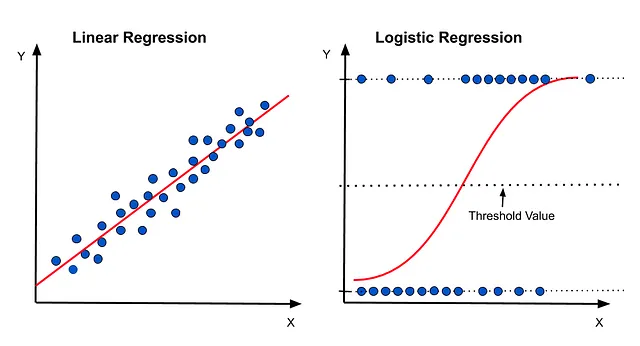

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("heart_disease.csv")
print(df.head())

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.dropna(inplace=True)
df.head()

In [ ]:
x = df.drop('target',axis=1)

x.head()

In [ ]:
y = df['target']
y.head()

In [ ]:
#pie chart to see the % of heart disease and not having heart disease
plt.figure(figsize=(6,6))
df['target'].value_counts().plot.pie(autopct="%1.1f%%",colors=['blue','red'])
plt.title("heart_disease distribution")
plt.ylabel("")
plt.show()

In [ ]:
#%pip install seaborn
import seaborn as sns
plt.figure(figsize=(6,6))
sns.histplot(df['age'],kde=True,color = 'orange')
plt.title('Age Distribution')
plt.xlabel('age')
plt.ylabel('Freuency')
plt.show()

In [ ]:
#logistic regresion model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y , test_size=0.2)

In [ ]:
y_test.head()

In [ ]:
x_test.head()


In [ ]:
scaler  = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scalert = scaler.transform(x_test)


x_test_scalert

In [ ]:
log_regrestion = LogisticRegression()

log_regrestion.fit(x_train_scaler,y_train)
# .pkl

In [ ]:
import pickle
with open('log_reg.pkl',mode='wb') as s:
    pickle.dump(log_regrestion,s)

In [ ]:
with open('scaler.pkl',mode='wb') as f:
    pickle.dump(scaler,f)

In [ ]:
print(x_test.head())
print(y_test.head())

In [ ]:
test_arr = np.array(x_test)
print(test_arr)

In [ ]:
test_scaler = scaler.transform(test_arr)
# Create 10 sample test cases
sample_cases = np.array([
    # [age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal]
        [67, 1, 4, 120, 229, 0, 2, 129, 1, 2.6, 2, 2, 7],
        [57, 1, 2, 124, 261, 0, 0, 141, 0, 0.3, 1, 0, 7],
        [64, 1, 4, 128, 263, 0, 0, 105, 1, 0.2, 2, 1, 7],
        [59, 1, 4, 135, 234, 0, 0, 161, 0, 0.5, 2, 0, 7],
        [46, 1, 4, 140, 311, 0, 0, 120, 1, 1.8, 2, 2, 7],
        [71, 0, 4, 112, 149, 0, 0, 125, 0, 1.6, 2, 0, 3],
        [60, 1, 4, 140, 293, 0, 2, 170, 0, 1.2, 2, 2, 7],
        [48, 0, 3, 130, 275, 0, 0, 139, 0, 0.2, 1, 0, 3],
        [40, 1, 1, 140, 199, 0, 0, 178, 1, 1.4, 1, 0, 7],
        [54, 0, 2, 132, 288, 1, 2, 159, 1, 0, 1, 1, 3]
])
rand_cas = scaler.transform(sample_cases)

In [ ]:
with open("log_reg.pkl",mode='rb') as f:
    logreg_model = pickle.load(f)
with open("scaler.pkl",mode='rb') as f:
    scal_model = pickle.load(f)

In [ ]:
predict_logreg = logreg_model.predict(test_scaler)
sample_predict_logreg = logreg_model.predict(rand_cas)
# print(x_test.head())
print(predict_logreg)
print(sample_predict_logreg)

In [ ]:
acc_logreg = accuracy_score(y_test,predict_logreg)
print(acc_logreg)

In [ ]:
calssificationreport = classification_report(y_test,predict_logreg)
print(calssificationreport)
#0 no heart disease
#1 heart disease

In [ ]:
plt.figure(figsize=(8,8))
cm  = confusion_matrix(y_test,predict_logreg)
sns.heatmap(cm,annot=True,cmap='Blues',cbar=False)
plt.show()